<a href="https://colab.research.google.com/github/mahir-rana/Accenture-1D-contract-review-challenge/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
REPO_DIR = "/content/Accenture-1D-contract-review-challenge"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Break-Through-Tech/Accenture-1D-contract-review-challenge/ {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

%cd {REPO_DIR}

In [18]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:


root_dir = "." # needs to be changed when working in Colab...

with open(f"{root_dir}/data/cuad/train_separate_questions.json") as f:
  data = json.load(f)

categories_df = pd.read_csv(f"{root_dir}/data/cuad/category_descriptions.csv")

# Stripping prefixes from each entry:
categories_df.rename(columns={"Category (incl. context and answer)": "Category"}, inplace=True)
categories_df = categories_df.apply(lambda col: col.astype(str).str.removeprefix(col.name).str.lstrip(": "))


In [ ]:
# Example data...
print(len(data["data"]))
print(data["data"][0]["title"])
print(len(data["data"][0]["paragraphs"][0]["qas"]))

408
LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
68


In [29]:
categories_df.head()

,Category,Description,Answer Format,Group
0,Document Name,The name of the contract,Contract Name,-
1,Parties,The two or more parties who signed the contract,Entity or individual names,-
2,Agreement Date,The date of the contract,Date (mm/dd/yyyy),1
3,Effective Date,The date when the contract is effective,Date (mm/dd/yyyy),1
4,Expiration Date,On what date will the contract's initial term ...,Date (mm/dd/yyyy) / Perpetual,1


## Flattening training json into a DataFrame

In [14]:
# Initial rough pass
train_df = pd.json_normalize(data["data"], record_path=["paragraphs", "qas"], meta=["title"])

print(train_df.shape)
train_df.head()


(22450, 5)


,answers,id,question,is_impossible,title
0,"[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_sta...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
1,"[{'text': 'Distributor', 'answer_start': 244}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
2,"[{'text': 'Electric City of Illinois L.L.C.', ...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
3,"[{'text': 'Electric City of Illinois LLC', 'an...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
4,"[{'text': 'Company', 'answer_start': 197}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...


## Questions


In [ ]:
train_df['question'].nunique() 
# 41 unique values

41

In [ ]:
# a question looks like this:
train_df['question'][0] # interesting it renders differently...

'Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract'

Add a `Category` column to `train_df`, corresponding to the column in `categories_df`.

In [21]:
train_df['Category'] = train_df['question'].str.extract(r'"([^"]+)"')

In [23]:
train_df.head()

,answers,id,question,is_impossible,title,Category
0,"[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_sta...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name
1,"[{'text': 'Distributor', 'answer_start': 244}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties
2,"[{'text': 'Electric City of Illinois L.L.C.', ...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties
3,"[{'text': 'Electric City of Illinois LLC', 'an...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties
4,"[{'text': 'Company', 'answer_start': 197}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties


Now we can visualize the distribution of Categories:

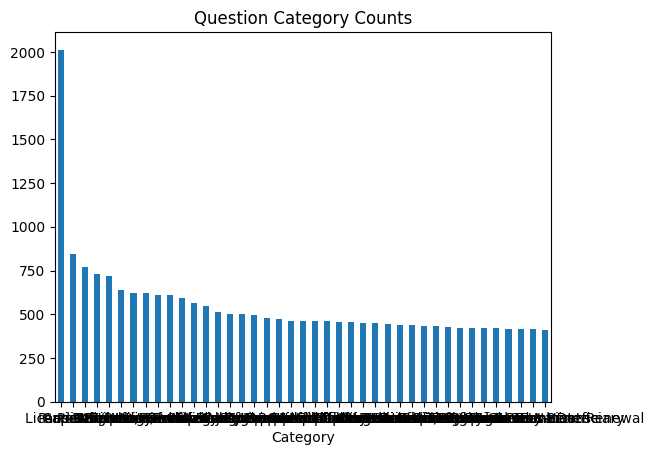

In [ ]:
train_df['Category'].value_counts().plot.bar(rot=0)
plt.title('Question Category Counts')
plt.show()
# TODO: make this prettier. split into multiple identically scaled subplots?


In [31]:
print('The majority of questions are under the category', train_df['Category'].value_counts().idxmax())

The majority of questions are under the category Parties


This gets a rough extraction. Can we trivialize some keys of the original json? It seems the paragraphs and answers keys are always length <= 1. Confirming:

In [ ]:


from collections import Counter

paragraphs_lens = Counter(len(c['paragraphs']) for c in data['data'])
print("paragraphs lengths:", paragraphs_lens)

answers_lens = Counter(
    len(qa['answers'])
    for c in data['data']
    for p in c['paragraphs']
    for qa in p['qas']
)
print("answers lengths:", answers_lens)

paragraphs lengths: Counter({1: 408})
answers lengths: Counter({0: 11270, 1: 11180})


All documents in the training set correspond to exactly one paragraph, so paragraph doesn't need to be a separate column.\
The key answer is either of length 0 or 1. The contents of answer look like:

In [15]:
train_df['answers'][0]

[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}]